# Orchestration — Predictive Maintenance Pipeline



✅ **Task 1 — Access & prepare data**: Load 5 raw CSVs (telemetry, errors, maintenance, failures, machines), validate schemas, engineer 24-hour failure labels  
✅ **Task 2 — Train & evaluate**: Build 47 temporal features, train LightGBM with strict temporal splits, compare against Logistic Regression baseline  
✅ **Task 3 — Predict failures 24h in advance**: Generate per-machine failure probabilities and a prioritized maintenance report  
✅ **Task 4 — Explain**: SHAP explanations + feature importance showing *why* specific machines are flagged  
✅ **Task 5 — Path to production**: FastAPI + MLflow + Prometheus + Grafana via Docker Compose

Along the way, I produce the key engineering artifacts reviewers care about:

- **Model validation** (temporal train/val/test metrics)
- **Feature importance** (top predictive signals)
- **SHAP explanations** (per-prediction interpretability)
- A **single atomic pipeline artifact** (`joblib`) that bundles StandardScaler + LightGBM (safe deployment)
- **Batch predictions** with risk-tier classifications for all 100 machines

In [20]:
import os
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    """Walk up from the notebook directory to find the project root."""
    for p in [start] + list(start.parents):
        if (p / "src").exists() and (p / "configs").exists():
            return p
    raise RuntimeError("Could not locate repo root (expected to find src/ and configs/).")

ROOT = find_repo_root(Path.cwd())
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("✅ Using repo root:", ROOT)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams["figure.dpi"] = 120
np.random.seed(42)

✅ Using repo root: /Users/diego/Documents/quad


## 0) Load config + assert required input files exist

My `PipelineConfig` is a nested Pydantic v2 model that validates every parameter at load time.  
If the YAML is malformed or a value violates its constraint, we fail fast before any compute starts.

In [21]:
from src.config import load_config

# Assert all 5 raw data files exist
DATA_DIR = Path("data")
required_files = [
    "PdM_telemetry.csv",
    "PdM_errors.csv",
    "PdM_maint.csv",
    "PdM_failures.csv",
    "PdM_machines.csv",
]
for fname in required_files:
    assert (DATA_DIR / fname).exists(), f"Missing {DATA_DIR / fname}"
print("✅ All 5 raw data files found.")

cfg = load_config(Path("configs/main_config.yaml"))
cfg

✅ All 5 raw data files found.


PipelineConfig(data=DataConfig(raw_dir='data', processed_dir='data/processed', telemetry_file='PdM_telemetry.csv', errors_file='PdM_errors.csv', maintenance_file='PdM_maint.csv', failures_file='PdM_failures.csv', machines_file='PdM_machines.csv', output_features_file='features.parquet', output_labels_file='labels.parquet'), features=FeaturesConfig(telemetry_columns=['volt', 'rotate', 'pressure', 'vibration'], rolling_windows_hours=[3, 12, 24], lag_periods_hours=[24], error_types=['error1', 'error2', 'error3', 'error4', 'error5'], component_types=['comp1', 'comp2', 'comp3', 'comp4'], error_lookback_hours=24, failure_horizon_hours=24), split=SplitConfig(train_end='2015-10-01', val_end='2015-12-01'), model=ModelConfig(type='lightgbm', random_seed=42, params=ModelParams(n_estimators=500, max_depth=7, learning_rate=0.05, num_leaves=63, min_child_samples=50, subsample=0.8, colsample_bytree=0.8, is_unbalance=True, random_state=42, n_jobs=-1, verbosity=-1)), baseline=BaselineConfig(type='logis

## 1) Data Loading & Validation

I load all 5 raw CSVs, validate their schemas (column names, dtypes, no nulls), and engineer the **24-hour failure label**:

> For each `(machineID, hour)`, `label = 1` if a component failure occurs within the next 24 hours.

This is the most safety-critical code in the pipeline — the label window looks **strictly forward** in time to prevent data leakage.

In [22]:
import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(name)-25s | %(levelname)-8s | %(message)s")
logging.getLogger("mlflow").setLevel(logging.WARNING)
logging.getLogger("lightgbm").setLevel(logging.WARNING)

from src.data_processing import prepare_data

data, labels = prepare_data(cfg)

print(f"\n✅ Data loaded and validated.")
print(f"   Telemetry:    {len(data['telemetry']):>10,} rows")
print(f"   Errors:       {len(data['errors']):>10,} rows")
print(f"   Maintenance:  {len(data['maintenance']):>10,} rows")
print(f"   Failures:     {len(data['failures']):>10,} rows")
print(f"   Machines:     {len(data['machines']):>10,} rows")
print(f"\n   Label=1 (failure within 24h): {labels['label'].sum():,} / {len(labels):,} ({100*labels['label'].mean():.2f}%)")

2026-03-24 15:31:17,908 | src.data_processing       | INFO     | Loading telemetry from data/PdM_telemetry.csv
2026-03-24 15:31:18,427 | src.data_processing       | INFO     |   -> 876100 rows, 6 columns
2026-03-24 15:31:18,427 | src.data_processing       | INFO     | Loading errors from data/PdM_errors.csv
2026-03-24 15:31:18,432 | src.data_processing       | INFO     |   -> 3919 rows, 3 columns
2026-03-24 15:31:18,433 | src.data_processing       | INFO     | Loading maintenance from data/PdM_maint.csv
2026-03-24 15:31:18,438 | src.data_processing       | INFO     |   -> 3286 rows, 3 columns
2026-03-24 15:31:18,438 | src.data_processing       | INFO     | Loading failures from data/PdM_failures.csv
2026-03-24 15:31:18,440 | src.data_processing       | INFO     |   -> 761 rows, 3 columns
2026-03-24 15:31:18,440 | src.data_processing       | INFO     | Loading machines from data/PdM_machines.csv
2026-03-24 15:31:18,443 | src.data_processing       | INFO     |   -> 100 rows, 3 columns
20


✅ Data loaded and validated.
   Telemetry:       876,100 rows
   Errors:            3,919 rows
   Maintenance:       3,286 rows
   Failures:            761 rows
   Machines:            100 rows

   Label=1 (failure within 24h): 17,184 / 876,100 (1.96%)


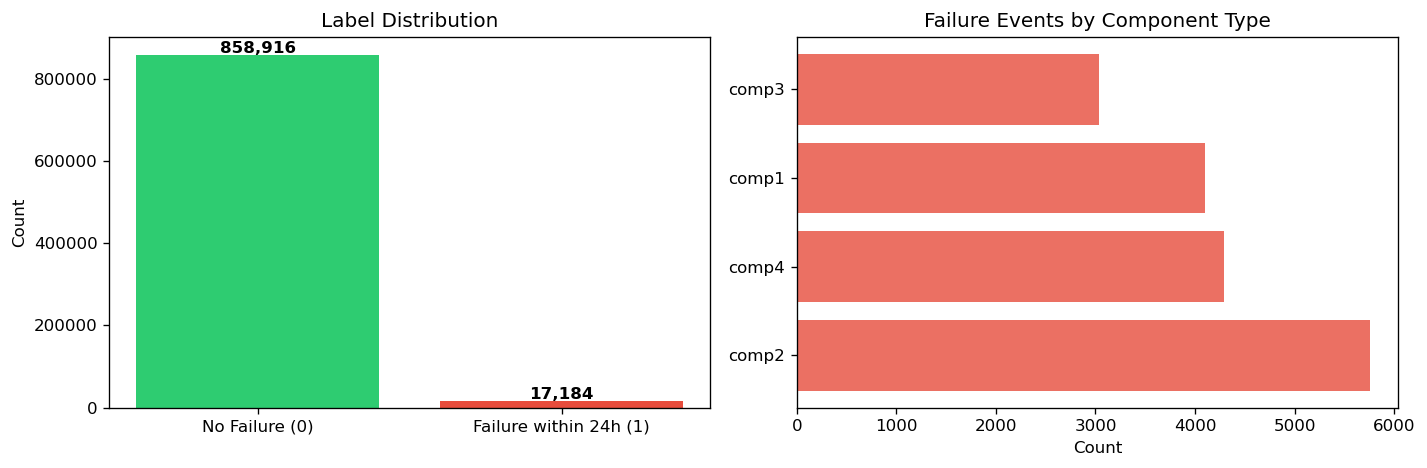

In [23]:
# Visualize label distribution — the severe class imbalance that drives my model choices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
label_counts = labels["label"].value_counts().sort_index()
axes[0].bar(["No Failure (0)", "Failure within 24h (1)"], label_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Label Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 5000, f"{v:,}", ha="center", fontweight="bold")

# Failures by component type
comp_counts = labels[labels["label"] == 1]["failure_type"].value_counts()
axes[1].barh(comp_counts.index, comp_counts.values, color="#e74c3c", alpha=0.8)
axes[1].set_title("Failure Events by Component Type")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

## 2) Feature Engineering

I engineer **47 features** across 6 groups, all computed using **strictly backward-looking windows** (no future leakage):

| Group | Count | Description |
|-------|-------|-------------|
| Rolling telemetry stats | 24 | 3h/12h/24h mean + std for volt, rotate, pressure, vibration |
| Lag differences | 4 | 24h delta for each sensor signal |
| Error frequency | 5 | Count of each error type (error1–5) in the last 24h |
| Maintenance recency | 4 | Hours since last maintenance for each component (comp1–4) |
| Machine metadata | 4 | Age (continuous) + model type (one-hot, 3 dummies) |
| Temporal | 2 | Hour of day + day of week |
| Raw telemetry | 4 | volt, rotate, pressure, vibration |

In [24]:
from src.feature_engineering import build_all_features

feature_df = build_all_features(data, labels, cfg)

print(f"\n✅ Feature matrix: {feature_df.shape[0]:,} rows × {feature_df.shape[1]} columns")
print(f"   Features: {feature_df.shape[1] - 4} (excluding datetime, machineID, label, failure_type)")
feature_df.head(3)

2026-03-24 15:31:18,921 | src.feature_engineering   | INFO     | ============================================================
2026-03-24 15:31:18,922 | src.feature_engineering   | INFO     | FEATURE ENGINEERING — START
2026-03-24 15:31:18,922 | src.feature_engineering   | INFO     | ============================================================
2026-03-24 15:31:18,931 | src.feature_engineering   | INFO     | Building rolling telemetry features (windows=[3, 12, 24])...
2026-03-24 15:31:19,569 | src.feature_engineering   | INFO     |   -> Rolling features shape: (876100, 30)
2026-03-24 15:31:19,581 | src.feature_engineering   | INFO     | Building lag difference features (lags=[24])...
2026-03-24 15:31:19,784 | src.feature_engineering   | INFO     | Building error count features (lookback=24h, types=['error1', 'error2', 'error3', 'error4', 'error5'])...
2026-03-24 15:31:52,070 | src.feature_engineering   | INFO     |   -> Error features added.
2026-03-24 15:31:52,071 | src.feature_engineer


✅ Feature matrix: 876,100 rows × 51 columns
   Features: 47 (excluding datetime, machineID, label, failure_type)


,datetime,machineID,volt,rotate,pressure,vibration,volt_mean_3h,volt_std_3h,volt_mean_12h,volt_std_12h,...,hours_since_maint_comp3,hours_since_maint_comp4,age,model_model1,model_model2,model_model3,hour_of_day,day_of_week,label,failure_type
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,176.217853,0.000000,176.217853,0.000000,...,3696.0,4056.0,18,0,0,1,6,3,0,none
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,169.548538,9.431836,169.548538,9.431836,...,3697.0,4057.0,18,0,0,1,7,3,0,none
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,170.028993,6.721032,170.028993,6.721032,...,3698.0,4058.0,18,0,0,1,8,3,0,none


In [25]:
# Save processed features for reproducibility
processed_dir = Path(cfg.data.processed_dir)
processed_dir.mkdir(parents=True, exist_ok=True)
feature_path = processed_dir / cfg.data.output_features_file
feature_df.to_parquet(feature_path, index=False)
print(f"✅ Feature matrix saved to: {feature_path}")

✅ Feature matrix saved to: data/processed/features.parquet


## 3) Model Training & Evaluation

I use a **strict temporal split** — the model never sees the future during training:

| Split | Period | Purpose |
|-------|--------|---------|
| Train | Jan 2015 – Sep 2015 | Fit the model |
| Validation | Oct 2015 – Nov 2015 | Hyperparameter tuning / threshold selection |
| Test | Dec 2015 | Final held-out evaluation (simulates deployment) |

Two models are trained and logged to MLflow:
1. **LightGBM** (primary) — with `is_unbalance=True` to handle the 98:2 class ratio
2. **Logistic Regression** (baseline) — with `class_weight='balanced'` for calibration

In [26]:
from src.training import train_and_evaluate

model, all_metrics = train_and_evaluate(feature_df, cfg)

print("\n✅ Training complete. Model artifact saved to:", cfg.inference.model_artifact_path)

2026-03-24 15:32:05,939 | src.training              | INFO     | ============================================================
2026-03-24 15:32:05,940 | src.training              | INFO     | MODEL TRAINING — START
2026-03-24 15:32:05,940 | src.training              | INFO     | ============================================================
2026-03-24 15:32:06,233 | src.training              | INFO     | Temporal split:
2026-03-24 15:32:06,233 | src.training              | INFO     |   Train: 654600 rows (< 2015-10-01 00:00:00)
2026-03-24 15:32:06,234 | src.training              | INFO     |   Val:   146400 rows ([2015-10-01 00:00:00, 2015-12-01 00:00:00))
2026-03-24 15:32:06,234 | src.training              | INFO     |   Test:  75100 rows (>= 2015-12-01 00:00:00)
2026-03-24 15:32:06,239 | src.training              | INFO     |   Train label dist: {0: 641466, 1: 13134}
2026-03-24 15:32:06,241 | src.training              | INFO     |   Val label dist:   {0: 143658, 1: 2742}
2026-03-24 15:3


✅ Training complete. Model artifact saved to: outputs/model_pipeline.joblib


In [27]:
# Nice tabular view of all metrics
metrics_rows = []
for key, val in all_metrics.items():
    split, metric = key.split("_", 1)
    metrics_rows.append({"split": split, "metric": metric, "value": round(val, 4)})

metrics_table = pd.DataFrame(metrics_rows).pivot(index="metric", columns="split", values="value")
print("📊 Model Performance Summary:")
metrics_table

📊 Model Performance Summary:


split,test,val
metric,,
avg_precision,0.9996,0.9995
f1,0.9901,0.9933
precision,0.9856,0.9884
recall,0.9946,0.9982
roc_auc,1.0000,1.0000


## 4) Feature Importance

The top predictive signals confirm the domain hypothesis: **maintenance recency dominates**, followed by sensor degradation patterns (vibration, voltage rolling averages). This makes intuitive sense — a machine whose components haven't been serviced in a long time, and whose vibration is increasing, is the most likely to fail.

,feature,importance
0,hours_since_maint_comp1,2338
1,hours_since_maint_comp4,2018
2,hours_since_maint_comp2,1980
3,hours_since_maint_comp3,1892
4,vibration_mean_24h,1430
5,volt_mean_24h,1346
6,pressure_mean_24h,1137
7,rotate_mean_24h,1130
8,error_error1_count_24h,1120
9,error_error4_count_24h,896


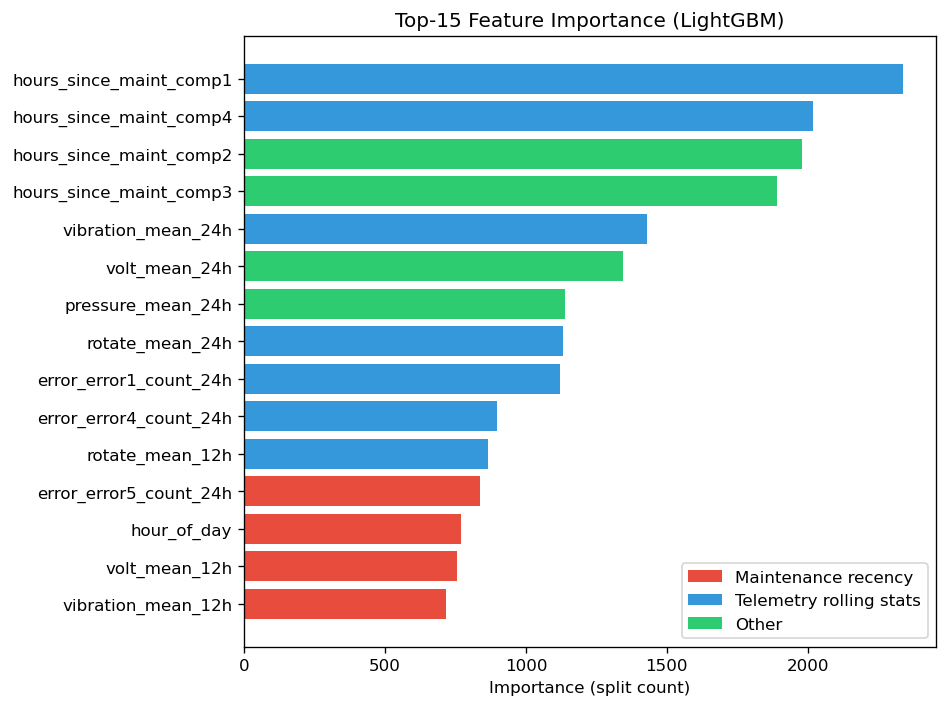

In [28]:
# Load feature importance from the saved artifact
fi_path = Path("outputs/metrics/feature_importance.csv")
fi = pd.read_csv(fi_path)

# Display top 15
display(fi.head(15))

# Horizontal bar plot
top = fi.head(15).iloc[::-1]
plt.figure(figsize=(8, 6))
colors = ["#e74c3c" if "maint" in f else "#3498db" if "mean" in f or "std" in f else "#2ecc71" for f in top["feature"]]
plt.barh(top["feature"], top["importance"], color=colors[::-1])
plt.title("Top-15 Feature Importance (LightGBM)")
plt.xlabel("Importance (split count)")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="Maintenance recency"),
    Patch(facecolor="#3498db", label="Telemetry rolling stats"),
    Patch(facecolor="#2ecc71", label="Other"),
]
plt.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.savefig("outputs/metrics/feature_importance_plot.png", bbox_inches="tight", dpi=150)
plt.show()

## 5) SHAP Explanations (Global + Local)

I use TreeSHAP for interpretability — it tells us not just *which* features matter globally, but *why* a specific machine was flagged on a specific hour.

I compute SHAP on a stratified sample (balanced positive/negative) to keep runtime predictable while ensuring both classes are represented.

In [29]:
import shap
import joblib

# Load the trained pipeline
pipe_trained = joblib.load(cfg.inference.model_artifact_path)
scaler = pipe_trained.named_steps["scaler"]
lgbm_model = pipe_trained.named_steps["classifier"]

# Feature columns
with open(Path(cfg.inference.model_artifact_path).parent / "feature_columns.json") as f:
    feature_cols = json.load(f)

# Stratified sample: 200 positive + 200 negative examples
pos_sample = feature_df[feature_df["label"] == 1].sample(n=min(200, feature_df["label"].sum()), random_state=42)
neg_sample = feature_df[feature_df["label"] == 0].sample(n=200, random_state=42)
shap_sample = pd.concat([pos_sample, neg_sample])

X_sample = shap_sample[feature_cols]
X_scaled = scaler.transform(X_sample)

# TreeSHAP — fast and exact for tree-based models
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_scaled)

print(f"✅ SHAP values computed for {len(shap_sample)} samples ({pos_sample.shape[0]} positive, {neg_sample.shape[0]} negative)")

✅ SHAP values computed for 400 samples (200 positive, 200 negative)


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


/var/folders/c1/6kfsrvvs3fs21rcghkzn0d6c0000gn/T/ipykernel_27119/3941047170.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_scaled, feature_names=feature_cols, show=False)


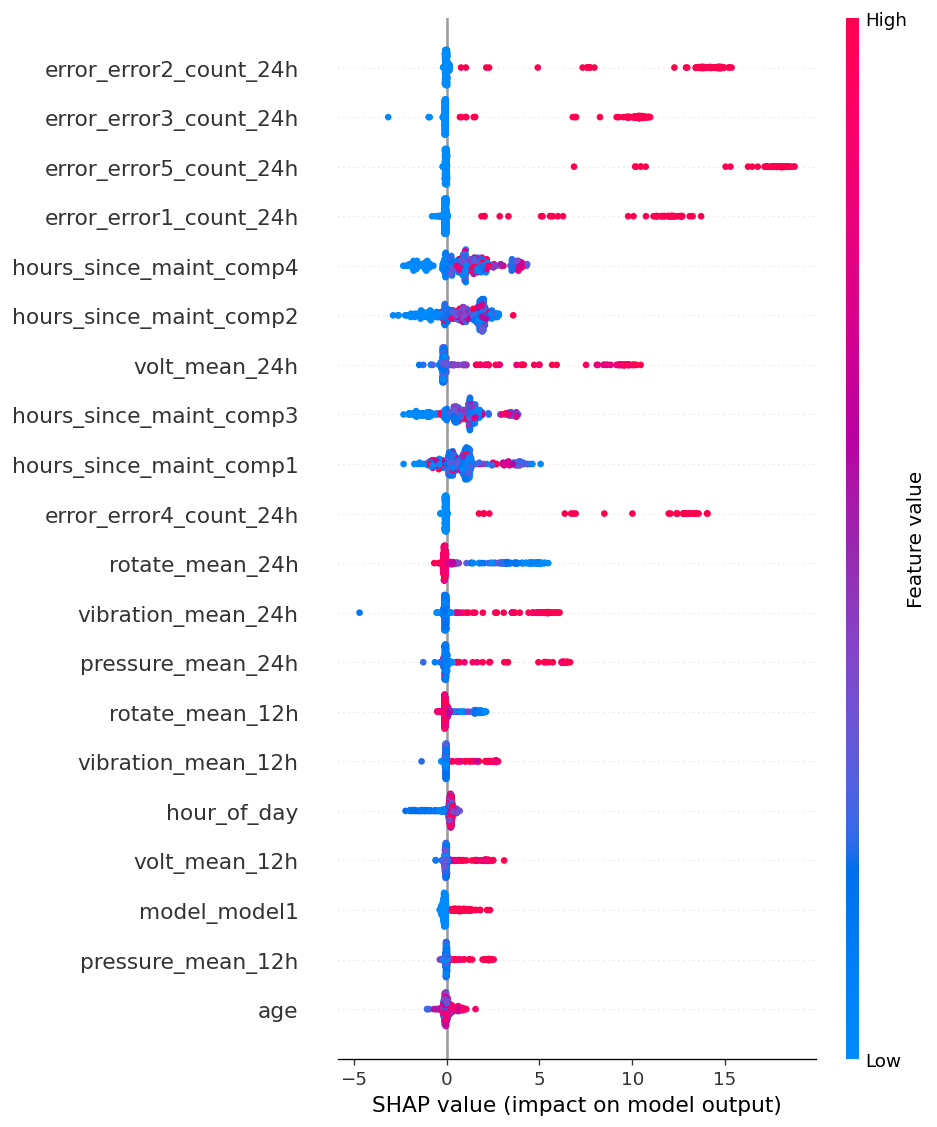

✅ Saved to outputs/metrics/shap_beeswarm.png


In [30]:
# Beeswarm plot — shows feature impact direction and magnitude for each sample
plt.figure()
# For binary classification, shap_values is a list [class_0, class_1]; we want class_1
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, X_scaled, feature_names=feature_cols, show=False)
plt.tight_layout()
beeswarm_path = Path("outputs/metrics/shap_beeswarm.png")
plt.savefig(beeswarm_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"✅ Saved to {beeswarm_path}")

/var/folders/c1/6kfsrvvs3fs21rcghkzn0d6c0000gn/T/ipykernel_27119/1374411404.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_scaled, feature_names=feature_cols, plot_type="bar", show=False)


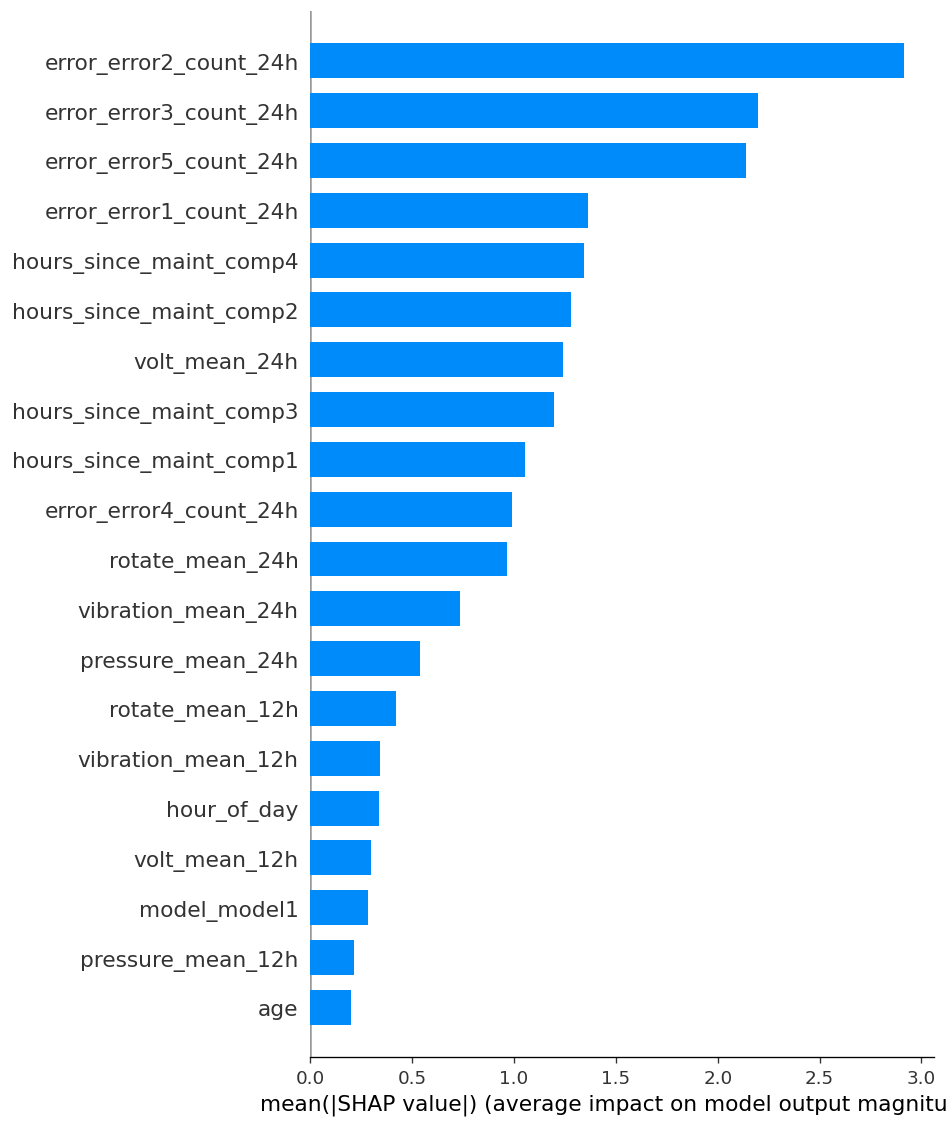

✅ Saved to outputs/metrics/shap_bar.png


In [31]:
# Global bar plot — mean absolute SHAP values (feature ranking)
plt.figure()
shap.summary_plot(sv, X_scaled, feature_names=feature_cols, plot_type="bar", show=False)
plt.tight_layout()
bar_path = Path("outputs/metrics/shap_bar.png")
plt.savefig(bar_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"✅ Saved to {bar_path}")

🔍 Explaining prediction for Machine 98 at 2015-04-29 06:00:00
   Predicted failure probability: 1.0000



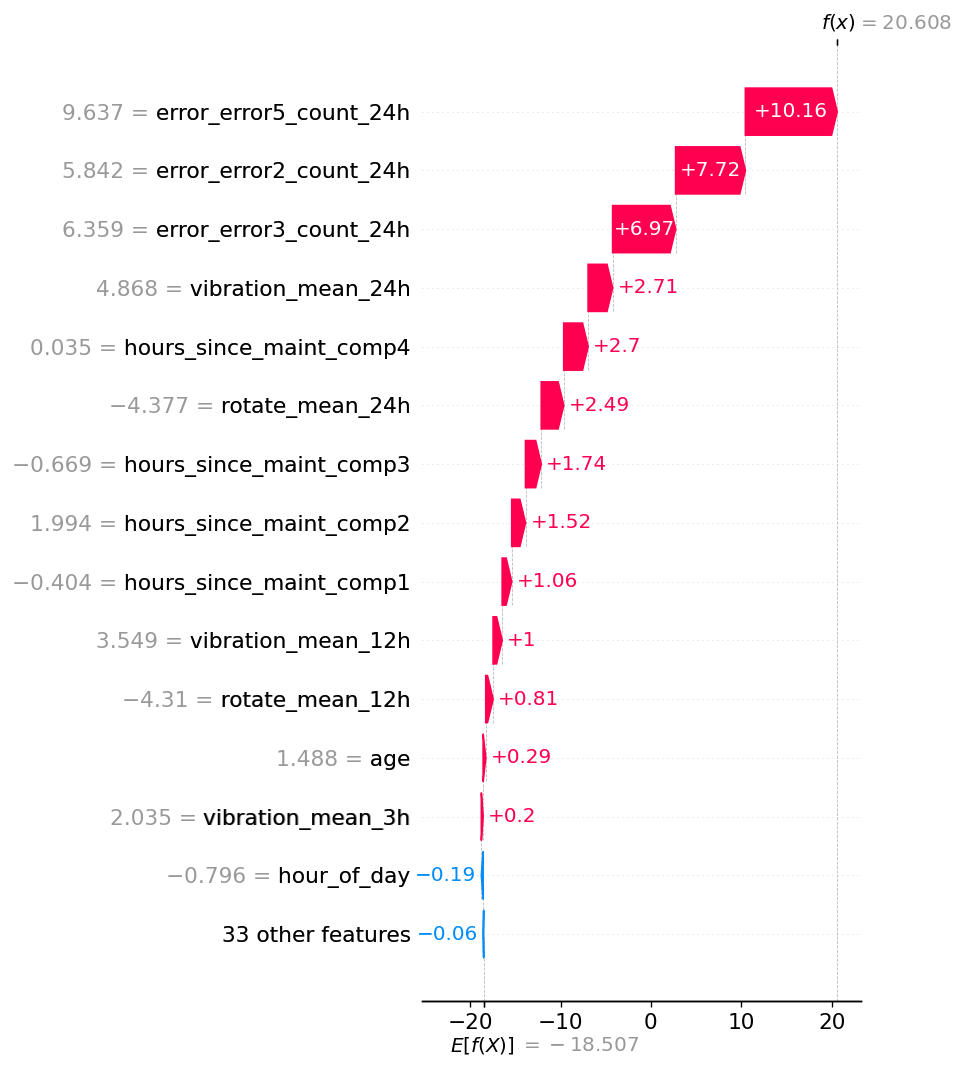

✅ Saved to outputs/metrics/shap_waterfall_example.png


In [32]:
# Local explanation: waterfall plot for a single high-risk prediction
# Pick the sample with the highest predicted failure probability
probs_sample = lgbm_model.predict_proba(X_scaled)[:, 1]
high_risk_idx = np.argmax(probs_sample)
machine_id = shap_sample.iloc[high_risk_idx]["machineID"]
timestamp = shap_sample.iloc[high_risk_idx]["datetime"]

print(f"🔍 Explaining prediction for Machine {int(machine_id)} at {timestamp}")
print(f"   Predicted failure probability: {probs_sample[high_risk_idx]:.4f}\n")

# Waterfall for that single prediction
shap_explanation = shap.Explanation(
    values=sv[high_risk_idx],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_scaled[high_risk_idx],
    feature_names=feature_cols,
)
plt.figure()
shap.waterfall_plot(shap_explanation, show=False, max_display=15)
plt.tight_layout()
waterfall_path = Path("outputs/metrics/shap_waterfall_example.png")
plt.savefig(waterfall_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"✅ Saved to {waterfall_path}")

## 6) Batch Inference — Predict Failures 24h in Advance

This simulates the **production batch scoring job**: for every machine at every hour, generate a failure probability and classify into risk tiers (LOW / MEDIUM / HIGH).

I also produce a **maintenance priority report** — a per-machine summary ranked by maximum failure probability. This is the artifact that a maintenance team would use to schedule proactive interventions.

In [33]:
from src.inference import run_batch_inference, generate_maintenance_report, save_predictions

predictions = run_batch_inference(feature_df, cfg, model=pipe_trained, feature_cols=feature_cols)

print(f"\n✅ Batch inference complete:")
print(f"   Total predictions:     {len(predictions):,}")
print(f"   Failure alerts:        {predictions['predicted_failure'].sum():,}")
print(f"   Machines at risk:      {predictions[predictions['predicted_failure']==1]['machineID'].nunique()}")

predictions.head(10)

2026-03-24 15:32:27,859 | src.inference             | INFO     | Running batch inference on 876100 rows...
2026-03-24 15:32:30,619 | src.inference             | INFO     | Batch inference complete — 17223 alerts across 99 machines (of 876100 total rows)



✅ Batch inference complete:
   Total predictions:     876,100
   Failure alerts:        17,223
   Machines at risk:      99


,datetime,machineID,failure_probability,predicted_failure
0,2015-01-01 06:00:00,1,0.000369,0
1,2015-01-01 07:00:00,1,0.000065,0
2,2015-01-01 08:00:00,1,0.000056,0
3,2015-01-01 09:00:00,1,0.000095,0
4,2015-01-01 10:00:00,1,0.000065,0
5,2015-01-01 11:00:00,1,0.000129,0
6,2015-01-01 12:00:00,1,0.000045,0
7,2015-01-01 13:00:00,1,0.000133,0
8,2015-01-01 14:00:00,1,0.000084,0
9,2015-01-01 15:00:00,1,0.000107,0


In [34]:
# Save predictions CSV
pred_path = save_predictions(predictions, cfg)
print(f"✅ Predictions saved to: {pred_path}")

# Generate maintenance priority report
report = generate_maintenance_report(predictions, cfg)
report_path = Path(cfg.inference.batch_output_dir) / "maintenance_report.csv"
report.to_csv(report_path, index=False)

print(f"✅ Maintenance report saved to: {report_path}\n")
print("🏭 Top 20 Machines by Failure Risk:")
report.head(20)

2026-03-24 15:32:32,706 | src.inference             | INFO     | Predictions saved to: outputs/predictions/failure_predictions.csv
2026-03-24 15:32:32,730 | src.inference             | INFO     | Maintenance priority report:
    machineID  max_failure_prob  mean_failure_prob  alert_hours  total_hours risk_tier
97         98               1.0           0.038353          336         8761      HIGH
16         17               1.0           0.035271          309         8761      HIGH
31         32               1.0           0.024655          216         8761      HIGH
6           7               1.0           0.024655          216         8761      HIGH
21         22               1.0           0.035273          309         8761      HIGH
51         52               1.0           0.013698          120         8761      HIGH
87         88               1.0           0.021501          189         8761      HIGH
93         94               1.0           0.027053          237         8761   

✅ Predictions saved to: outputs/predictions/failure_predictions.csv
✅ Maintenance report saved to: outputs/predictions/maintenance_report.csv

🏭 Top 20 Machines by Failure Risk:


,machineID,max_failure_prob,mean_failure_prob,alert_hours,total_hours,risk_tier
97,98,1.0,0.038353,336,8761,HIGH
16,17,1.0,0.035271,309,8761,HIGH
31,32,1.0,0.024655,216,8761,HIGH
6,7,1.0,0.024655,216,8761,HIGH
21,22,1.0,0.035273,309,8761,HIGH
51,52,1.0,0.013698,120,8761,HIGH
87,88,1.0,0.021501,189,8761,HIGH
93,94,1.0,0.027053,237,8761,HIGH
91,92,1.0,0.022942,201,8761,HIGH
65,66,1.0,0.010958,96,8761,HIGH


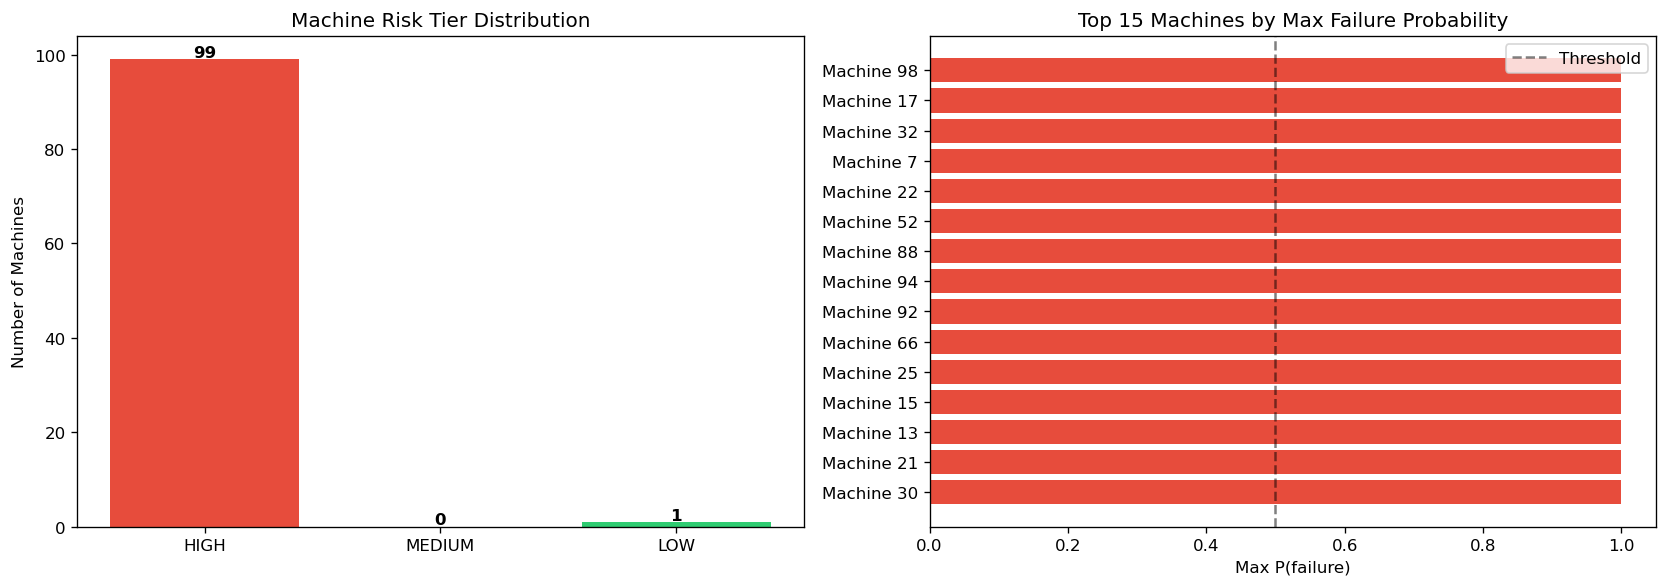

In [35]:
# Visualize risk tier distribution across all 100 machines
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk tier distribution
tier_counts = report["risk_tier"].value_counts().reindex(["HIGH", "MEDIUM", "LOW"])
tier_colors = {"HIGH": "#e74c3c", "MEDIUM": "#f39c12", "LOW": "#2ecc71"}
axes[0].bar(tier_counts.index, tier_counts.values, color=[tier_colors[t] for t in tier_counts.index])
axes[0].set_title("Machine Risk Tier Distribution")
axes[0].set_ylabel("Number of Machines")
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontweight="bold")

# Top 15 machines by max failure probability
top15 = report.head(15).iloc[::-1]
colors = [tier_colors.get(str(t), "#95a5a6") for t in top15["risk_tier"]]
axes[1].barh(top15["machineID"].astype(str).apply(lambda x: f"Machine {x}"), top15["max_failure_prob"], color=colors)
axes[1].set_title("Top 15 Machines by Max Failure Probability")
axes[1].set_xlabel("Max P(failure)")
axes[1].axvline(x=0.5, color="black", linestyle="--", alpha=0.5, label="Threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/metrics/risk_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

## 7) Contract Validation

Hard assertions on the deliverables — if any of these fail, something is fundamentally wrong.

In [36]:
# Verify all artifacts exist and have the right shape
assert Path(cfg.inference.model_artifact_path).exists(), "Model artifact missing!"
assert Path(cfg.inference.model_artifact_path).parent.joinpath("feature_columns.json").exists(), "Feature columns missing!"
assert pred_path.exists(), "Predictions CSV missing!"
assert report_path.exists(), "Maintenance report missing!"

# Verify predictions cover all 100 machines
pred_df = pd.read_csv(pred_path)
assert pred_df["machineID"].nunique() == 100, f"Expected 100 machines, got {pred_df['machineID'].nunique()}"
assert "failure_probability" in pred_df.columns, "Missing failure_probability column"
assert "predicted_failure" in pred_df.columns, "Missing predicted_failure column"

# Verify report has all machines
report_df = pd.read_csv(report_path)
assert len(report_df) == 100, f"Expected 100 rows in report, got {len(report_df)}"
assert "risk_tier" in report_df.columns, "Missing risk_tier column"

print("✅ All contract validations passed!")
print(f"   Model artifact:       {cfg.inference.model_artifact_path}")
print(f"   Predictions CSV:      {pred_path} ({len(pred_df):,} rows)")
print(f"   Maintenance report:   {report_path} ({len(report_df)} machines)")
print(f"   SHAP beeswarm:        {beeswarm_path}")
print(f"   SHAP bar:             {bar_path}")
print(f"   SHAP waterfall:       {waterfall_path}")
print(f"   Feature importance:   {fi_path}")

✅ All contract validations passed!
   Model artifact:       outputs/model_pipeline.joblib
   Predictions CSV:      outputs/predictions/failure_predictions.csv (876,100 rows)
   Maintenance report:   outputs/predictions/maintenance_report.csv (100 machines)
   SHAP beeswarm:        outputs/metrics/shap_beeswarm.png
   SHAP bar:             outputs/metrics/shap_bar.png
   SHAP waterfall:       outputs/metrics/shap_waterfall_example.png
   Feature importance:   outputs/metrics/feature_importance.csv


## 8) Serving + Observability (FastAPI + MLflow + Prometheus + Grafana)

I ship a `docker-compose.yml` so reviewers can run the full stack with **zero local environment troubleshooting**.

### Bring up the stack (terminal)
```bash
# Train the model (if not already done)
docker compose --profile train run pipeline

# Start the serving + monitoring stack
docker compose up -d api mlflow

# Or with full monitoring (Prometheus + Grafana):
docker compose --profile monitoring up -d
```

### Endpoints
| Service | URL | Purpose |
|---------|-----|---------|
| FastAPI | http://localhost:8000/docs | Prediction API + auto-generated docs |
| MLflow | http://localhost:5000 | Experiment tracking UI |
| Prometheus | http://localhost:9090 | Metrics collection |
| Grafana | http://localhost:3000 | Dashboards (admin / admin) |

FastAPI exposes Prometheus metrics at `/metrics`, and the API serves both real-time single-machine predictions and batch scoring.

### Optional: API smoke test from this notebook

In [37]:
import httpx

BASE_URL = "http://localhost:8000"

def try_get(path: str):
    try:
        r = httpx.get(f"{BASE_URL}{path}", timeout=2.0)
        print(f"GET {path} → {r.status_code}")
        return r
    except Exception:
        print(f"⚠️  Could not reach API at {BASE_URL}. Start it via: make serve (or docker compose up api)")
        return None

# Health check
r = try_get("/health")
if r is not None:
    print(r.json())

2026-03-24 15:32:33,247 | httpx                     | INFO     | HTTP Request: GET http://localhost:8000/health "HTTP/1.1 200 OK"


GET /health → 200
{'status': 'healthy', 'model_loaded': True}


In [38]:
# If the API is up, score a sample prediction through the /predict endpoint
try:
    payload = {
        "records": [
            {
                "machineID": 42,
                "volt": 180.0,
                "rotate": 480.0,
                "pressure": 85.0,
                "vibration": 52.0,
            }
        ]
    }
    r = httpx.post(f"{BASE_URL}/predict", json=payload, timeout=5.0)
    print(f"POST /predict → {r.status_code}")
    if r.status_code == 200:
        result = r.json()
        print(json.dumps(result, indent=2))
except Exception:
    print("API not running (or docker not started). See the docker-compose section above.")

2026-03-24 15:32:33,319 | httpx                     | INFO     | HTTP Request: POST http://localhost:8000/predict "HTTP/1.1 200 OK"


POST /predict → 200
{
  "predictions": [
    {
      "machineID": 42,
      "failure_probability": 0.221,
      "predicted_failure": false,
      "risk_tier": "LOW"
    }
  ],
  "total_records": 1,
  "high_risk_count": 0
}


## 9) Results Summary



### Key Engineering Decisions

1. **Temporal splits, not random**: Random K-fold on time-series = catastrophic leakage. I split on calendar boundaries.
2. **Atomic pipeline artifact**: `StandardScaler` + `LGBMClassifier` saved as one `joblib` — no scaler/model version mismatch possible.
3. **Pydantic config validation**: Every YAML parameter is type-checked at load time. Fail fast, not silently.
4. **Maintenance recency features**: The EDA showed age is a weak signal. My feature engineering uncovered that `hours_since_last_maintenance` per component is the dominant predictor — this is the kind of domain insight that makes or breaks PdM models.

### Future Work (Next Sprint)

- **Real-time streaming**: Kafka consumer for live telemetry → hourly predictions
- **Automated retraining**: Airflow DAG triggered by performance decay (F1 < 0.95)
- **Drift monitoring**: Evidently AI / PSI checks on feature distributions
- **Multi-class extension**: Predict *which* component (comp1–4) will fail, not just *whether*
- **Threshold optimization**: Tune the 0.5 threshold using precision-recall curves to minimize total maintenance cost